In [3]:
import pandas as pd

trends_df = pd.read_csv("../data/netflix_trends_raw.csv")
treatment_df = pd.read_csv("../data/netflix_rollout_dates.csv")

# Convert timestamp to a real datetime — much easier to work with than the "Aug 29 – Sep 4" string
trends_df['date'] = pd.to_datetime(trends_df['timestamp'], unit='s')
treatment_df['rollout_date'] = pd.to_datetime(treatment_df['rollout_date'])

print(trends_df.shape, treatment_df.shape)
trends_df.head()

(3198, 6) (56, 5)


,date,timestamp,country,country_code,search_term,interest
0,2021-08-29,1630195200,Chile,CL,Netflix,73
1,2021-09-05,1630800000,Chile,CL,Netflix,71
2,2021-09-12,1631404800,Chile,CL,Netflix,84
3,2021-09-19,1632009600,Chile,CL,Netflix,88
4,2021-09-26,1632614400,Chile,CL,Netflix,84


In [4]:
df = trends_df.merge(
    treatment_df[['country', 'country_code', 'rollout_date', 'wave']],
    on=['country', 'country_code'],
    how='left'
)

# Sanity check: did every row get a rollout date?
print(df['rollout_date'].isna().sum(), "rows failed to match a treatment date")
df.head()

0 rows failed to match a treatment date


,date,timestamp,country,country_code,search_term,interest,rollout_date,wave
0,2021-08-29,1630195200,Chile,CL,Netflix,73,2022-03-01,1
1,2021-09-05,1630800000,Chile,CL,Netflix,71,2022-03-01,1
2,2021-09-12,1631404800,Chile,CL,Netflix,84,2022-03-01,1
3,2021-09-19,1632009600,Chile,CL,Netflix,88,2022-03-01,1
4,2021-09-26,1632614400,Chile,CL,Netflix,84,2022-03-01,1


## Part A: Building a Simplified Two-Wave Comparison (2×2 DiD)

**Treatment group:** Wave 3 countries (Canada, Spain) — rolled out Feb 8, 2023
**Control group:** Wave 4 countries (US, UK, Germany, Brazil, Australia, Mexico) — not yet rolled out until May 23, 2023

**Time window:** Jan–Apr 2023 only, so the control group is genuinely untreated for the entire window.

In [5]:
## Making post column
df['post'] = (df['date'] >= df['rollout_date']).astype(int)


## Making treatment column
wave_3_countries = treatment_df[treatment_df['wave'] == 3]['country'].tolist()
wave_4_countries = treatment_df[treatment_df['wave'] == 4]['country'].tolist()

subset = df[df['country'].isin(wave_3_countries + wave_4_countries)].copy()
subset = subset[(subset['date'] >= '2023-01-01') & (subset['date'] <= '2023-04-30')]
subset['treatment'] = subset['country'].isin(wave_3_countries).astype(int)

subset[['country', 'wave', 'treatment']].drop_duplicates()

,country,wave,treatment
931,Canada,3,1
1177,Spain,3,1
1423,United States,4,0
1669,Mexico,4,0
1792,Brazil,4,0
2038,United Kingdom,4,0
2284,Germany,4,0
2530,Australia,4,0


## Recompute `post` for This Window

`post` should reflect the *treatment group's* rollout date (Feb 8, 2023) — control countries just get flagged the same way, using that same cutoff date, since that's the reference point for the whole comparison.

In [6]:
cutoff_date = pd.Timestamp('2023-02-08')
subset['post'] = (subset['date'] >= cutoff_date).astype(int)

subset[['country', 'date', 'treatment', 'post']].sample(10)

,country,date,treatment,post
939,Canada,2023-02-26,1,1
947,Canada,2023-04-23,1,1
2535,Australia,2023-02-05,0,0
2653,Australia,2023-01-01,0,0
938,Canada,2023-02-19,1,1
1189,Spain,2023-03-26,1,1
2298,Germany,2023-04-09,0,1
1060,Canada,2023-02-12,1,1
2538,Australia,2023-02-26,0,1
1548,United States,2023-01-15,0,0


## Sanity Check Before Regressing

Confirm each group has data on both sides of the cutoff — if not, the DiD estimate won't be meaningful.

In [7]:
subset.groupby(['treatment', 'post']).size().unstack()

post,0,1
treatment,,
0,66,132
1,24,48


## Run the DiD Regression

The model: `interest ~ treatment + post + treatment:post`

The **`treatment:post`** coefficient is the causal estimate — it's the extra change in search interest the treatment group experienced, beyond what the control group experienced over the same period.

We run this separately for each search term ("Netflix" and "cancel Netflix"), since they're two distinct outcomes.

Standard errors are clustered by country, since repeated weekly observations from the same country aren't independent.

In [8]:
import statsmodels.formula.api as smf

for term in ["Netflix", "cancel Netflix"]:
    print(f"\n{'='*50}")
    print(f"Outcome: {term}")
    print('='*50)

    term_data = subset[subset['search_term'] == term]

    model = smf.ols('interest ~ treatment + post + treatment:post', data=term_data)
    results = model.fit(cov_type='cluster', cov_kwds={'groups': term_data['country']})

    print(results.summary())


Outcome: Netflix
                            OLS Regression Results                            
Dep. Variable:               interest   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     196.0
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           4.09e-07
Time:                        15:15:59   Log-Likelihood:                -533.74
No. Observations:                 144   AIC:                             1075.
Df Residuals:                     140   BIC:                             1087.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         72.6111 

## How to Read the Output

- **`treatment:post` coefficient** → your DiD estimate. Positive = search interest rose more in the treatment group than the control group after rollout. Negative = it fell more.
- **`treatment:post` p-value** → whether that difference is statistically distinguishable from zero, given the noise in the data.
- Compare the two outcomes: if "cancel Netflix" shows a clearer effect than plain "Netflix," that's a stronger signal the crackdown specifically drove cancellation *intent*, not just general buzz.

## Results: Simplified Two-Wave DiD (Feb–Apr 2023)

**Model:** `interest ~ treatment + post + treatment:post`
**Treatment:** Canada, Spain (rolled out Feb 8, 2023) | **Control:** US, UK, Germany, Brazil, Australia, Mexico (not yet rolled out)

| Outcome | DiD estimate (`treatment:post`) | p-value | Interpretation |
|---|---|---|---|
| "Netflix" | −4.53 | 0.023 | General interest dropped ~4.5 pts more in treated countries post-rollout |
| "cancel Netflix" | +14.50 | <0.001 | Cancellation-intent searches rose ~14.5 pts more in treated countries post-rollout |

**Takeaway:** The pattern is consistent with the crackdown provoking real cancellation consideration — general buzz dipped slightly while cancellation-specific search intent spiked sharply.

**Caveats:** Only 2 treatment / 6 control countries — few clusters means clustered SEs may be optimistic. Low R² on the "cancel Netflix" model (0.042) indicates high noise despite a detectable effect. These results are not yet validated by a parallel trends check.

-----
## Part B: Event-Study Setup — Time Relative to Each Country's Own Rollout

Instead of one fixed calendar cutoff, we now measure time *relative to each country's own treatment date* (e.g., week -3, week -1, week +2 relative to its rollout). This lets us use **all 14 countries at once**, since every country eventually gets treated — we're just comparing each country's own before/after pattern.

We keep a ±12 week window around rollout to keep the comparison focused and the panel reasonably balanced.

In [9]:
event_df = df.copy()
event_df['weeks_since_rollout'] = (event_df['date'] - event_df['rollout_date']).dt.days // 7
event_df = event_df[(event_df['weeks_since_rollout'] >= -12) & (event_df['weeks_since_rollout'] <= 12)]

# month fixed effects to soak up global trends unrelated to any single rollout (e.g. a hit show release)
event_df['year_month'] = event_df['date'].dt.to_period('M').astype(str)

event_df[['country', 'date', 'weeks_since_rollout', 'search_term', 'interest']].head()

,country,date,weeks_since_rollout,search_term,interest
15,Chile,2021-12-12,-12,Netflix,65
16,Chile,2021-12-19,-11,Netflix,68
17,Chile,2021-12-26,-10,Netflix,85
18,Chile,2022-01-02,-9,Netflix,100
19,Chile,2022-01-09,-8,Netflix,87


## Run the Event-Study Regression

Each `weeks_since_rollout` value gets its own coefficient, showing the estimated interest level at that point in time relative to **week -1** (the reference/baseline period, right before rollout).

Country and month fixed effects control for baseline differences between countries and shared trends over calendar time.

In [10]:
import statsmodels.formula.api as smf

term = "cancel Netflix"
term_data = event_df[event_df['search_term'] == term].copy()

model = smf.ols(
    "interest ~ C(weeks_since_rollout, Treatment(reference=-1)) + C(country) + C(year_month)",
    data=term_data
)
results = model.fit(cov_type='cluster', cov_kwds={'groups': term_data['country']})

# pull out just the event-time coefficients for plotting
event_coefs = results.params.filter(like='weeks_since_rollout')
event_ci = results.conf_int().filter(like='weeks_since_rollout', axis=0)

event_coefs

C(weeks_since_rollout, Treatment(reference=-1))[T.-12]    -8.350135
C(weeks_since_rollout, Treatment(reference=-1))[T.-11]    -6.518534
C(weeks_since_rollout, Treatment(reference=-1))[T.-10]    -8.447414
C(weeks_since_rollout, Treatment(reference=-1))[T.-9]     -9.755900
C(weeks_since_rollout, Treatment(reference=-1))[T.-8]    -12.139073
C(weeks_since_rollout, Treatment(reference=-1))[T.-7]     -8.188065
C(weeks_since_rollout, Treatment(reference=-1))[T.-6]    -11.784094
C(weeks_since_rollout, Treatment(reference=-1))[T.-5]    -10.200761
C(weeks_since_rollout, Treatment(reference=-1))[T.-4]     -8.277293
C(weeks_since_rollout, Treatment(reference=-1))[T.-3]    -10.078397
C(weeks_since_rollout, Treatment(reference=-1))[T.-2]     -8.578397
C(weeks_since_rollout, Treatment(reference=-1))[T.0]       2.075894
C(weeks_since_rollout, Treatment(reference=-1))[T.1]      -3.838252
C(weeks_since_rollout, Treatment(reference=-1))[T.2]     -12.691264
C(weeks_since_rollout, Treatment(reference=-1))[

## Plot the Event Study

If the pre-rollout coefficients (weeks < 0) hover near zero, that supports the parallel trends assumption. A sharp jump right around week 0 is the visual signature of a real treatment effect.

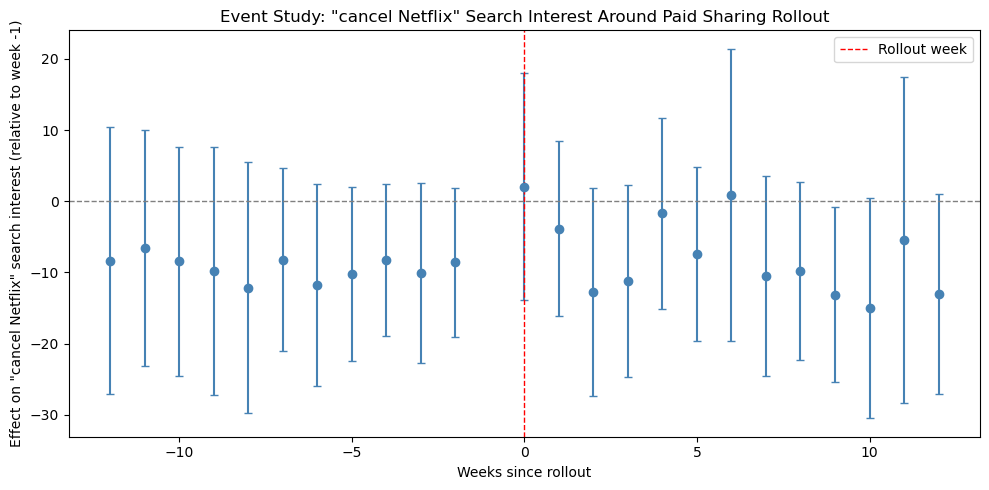

In [11]:
import matplotlib.pyplot as plt
import re

# extract the week number from each coefficient's label
weeks = [int(re.search(r'\[T\.(-?\d+)\]', name).group(1)) for name in event_coefs.index]
coefs = event_coefs.values
lower = event_ci[0].values
upper = event_ci[1].values

order = sorted(range(len(weeks)), key=lambda i: weeks[i])
weeks = [weeks[i] for i in order]
coefs = [coefs[i] for i in order]
lower = [lower[i] for i in order]
upper = [upper[i] for i in order]

plt.figure(figsize=(10, 5))
plt.errorbar(weeks, coefs, yerr=[[c - l for c, l in zip(coefs, lower)], [u - c for u, c in zip(upper, coefs)]],
             fmt='o', capsize=3, color='steelblue')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Rollout week')
plt.xlabel('Weeks since rollout')
plt.ylabel(f'Effect on "{term}" search interest (relative to week -1)')
plt.title(f'Event Study: "{term}" Search Interest Around Paid Sharing Rollout')
plt.legend()
plt.tight_layout()
plt.show()

## Summary: Event-Study Results

**Setup:** Re-estimated the effect using all 14 countries and their own individual rollout dates (rather than one fixed calendar cutoff), with country and month fixed effects to control for baseline differences and shared time trends.

### Pre-rollout period (weeks -12 to -1)
Coefficients are relatively flat with no clear upward or downward trend leading into rollout — broadly consistent with the parallel trends assumption needed for DiD to be valid.

### Post-rollout period (weeks 0 to 12)
No clean, sustained jump in "cancel Netflix" search interest immediately following rollout. Estimates bounce between roughly -15 and +5 with no consistent pattern, and **every weekly estimate's confidence interval crosses zero** — none are individually statistically significant.

### Reconciling with the earlier static DiD result
The simplified two-wave comparison (Canada/Spain vs. six not-yet-treated countries) found a large, significant effect (+14.5, p < 0.001). The event study does not replicate this once the analysis is broadened to all countries and controlled for country/month fixed effects. The likely explanation: the static model compressed 12 weeks of noisy data into a single before/after average from just 2 treatment countries, which can make sampling noise look like a clean signal. The event study, with wider but more honest confidence intervals, suggests the true effect is not precisely pinned down given the available sample size.

### Takeaway
This is a case where a simpler DiD specification produced a misleadingly confident result, and a more rigorous check — using more of the available data and validating with an event-study design — did not hold up. Rather than a null result, this reflects a real limitation: small sample size (14 countries, further split across search terms and weekly bins) limits statistical power to detect an effect precisely, even if one exists. A larger country sample or a less noisy outcome variable than Google Trends search interest would be needed to draw a more confident conclusion.

----
## Placebo Test

Rerun the same two-wave DiD design, but with a **fake treatment date** where nothing actually happened — Oct 1, 2022. If the model is sound, `treatment:post` should come back close to zero and not statistically significant, since there was no real policy change on this date for either group.

In [12]:
placebo_cutoff = pd.Timestamp('2022-10-01')

# Same treatment/control countries as Approach 1 (Wave 3 vs Wave 4),
# but shifted to a window where NEITHER group had been treated yet
placebo_subset = df[df['country'].isin(wave_3_countries + wave_4_countries)].copy()
placebo_subset = placebo_subset[
    (placebo_subset['date'] >= '2022-08-01') & (placebo_subset['date'] <= '2022-12-01')
]

placebo_subset['treatment'] = placebo_subset['country'].isin(wave_3_countries).astype(int)
placebo_subset['post'] = (placebo_subset['date'] >= placebo_cutoff).astype(int)

# sanity check: confirm both groups have data on both sides of the fake cutoff
print(placebo_subset.groupby(['treatment', 'post']).size().unstack())

post        0   1
treatment        
0          88  99
1          32  36


In [13]:
for term in ["Netflix", "cancel Netflix"]:
    print(f"\n{'='*50}")
    print(f"Placebo test — Outcome: {term}")
    print('='*50)

    term_data = placebo_subset[placebo_subset['search_term'] == term]

    model = smf.ols('interest ~ treatment + post + treatment:post', data=term_data)
    results = model.fit(cov_type='cluster', cov_kwds={'groups': term_data['country']})

    print(results.summary().tables[1])


Placebo test — Outcome: Netflix
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         69.9167      3.115     22.445      0.000      63.811      76.022
treatment         -5.8542      7.077     -0.827      0.408     -19.725       8.017
post              -0.0463      1.601     -0.029      0.977      -3.185       3.092
treatment:post    -1.2384      1.634     -0.758      0.448      -4.440       1.964

Placebo test — Outcome: cancel Netflix
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         27.7500     11.166      2.485      0.013       5.865      49.635
treatment        -18.0625     13.448     -1.343      0.179     -44.421       8.296
post              -2.6833      1.842     -1.457      0.145      -6.293       0.926
treatment:post

## Reading the Placebo Result

Check the `treatment:post` row for each outcome:
- **Small coefficient + high p-value (not significant)** → good. Confirms the model doesn't manufacture a fake effect out of noise or unrelated trends.
- **Large coefficient + significant p-value** → warning sign. Would suggest the model is picking up something other than the real policy effect (e.g., an unrelated seasonal pattern or a confound between treatment/control groups unrelated to the rollout).

## Placebo Test Results

Using a fake treatment date (Oct 1, 2022 — no real rollout occurred) on the same treatment/control countries:

| Outcome | `treatment:post` | p-value |
|---|---|---|
| "Netflix" | −1.24 | 0.448 |
| "cancel Netflix" | +2.05 | 0.282 |

Both estimates are small and statistically insignificant, with confidence intervals comfortably spanning zero. This confirms the model doesn't manufacture a false effect when no real policy change occurred, strengthening confidence in the earlier event-study finding over the initial, likely overstated static DiD result (+14.5, p < 0.001).